# Analisis de Elasticidad Precio — OfficeMax
## Categoria: SUMINISTROS DE OFICINA | Reto Tec

**Modelo log-log OLS:**
$$\log(\text{unidades}+1) = \alpha + \beta \cdot \log(\text{precio})$$

| Valor de beta | Tipo | Accion sugerida |
|:---:|:---:|:---|
| beta < -1 | Elastico | Bajar precio o promover |
| -1 < beta < 0 | **Inelastico** | Subir precio |
| beta > 0 | Atipico | No recomendable |

---
**Estructura:**
1. Carga y limpieza de datos
2. Modelo 1A — beta mensual por SKU
3. Modelos 1B/1C — ventanas rolling trimestral y semestral
4. Modelo 2 — OLS extendido con tienda, mes, premium
5. Simulador de elasticidad (+/-10% de precio)
6. Recomendaciones finales por SKU
7. Calendario mensual de accion + heatmap
8. Casos inelasticos temporales
9. Conclusion ejecutiva


---
## 1. Configuracion y carga de datos

In [1]:
CATEGORIA = "SUMINISTROS DE OFICINA"
BASE      = r"C:\Users\ramir\OneDrive\Escritorio\datos_officmax"
DESKTOP   = r"C:\Users\ramir\OneDrive\Escritorio"
MIN_OBS   = 3
MIN_CV    = 0.02
MIN_R2    = 0.0
MAX_BETA  = 10

import pandas as pd, numpy as np, matplotlib.pyplot as plt, os, glob, warnings
import matplotlib.backends.backend_pdf as pdf_backend
from sklearn.preprocessing import OneHotEncoder
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 10})
warnings.filterwarnings("ignore")

def find(base, pat):
    m = glob.glob(os.path.join(base, pat))
    if not m: raise FileNotFoundError(pat)
    return m[0]

ventas   = pd.read_csv(find(BASE, "Ventas_OfficeMax.csv"),       encoding="latin-1", low_memory=False)
catalogo = pd.read_csv(find(BASE, "Cat*.csv"),                   encoding="latin-1", low_memory=False)
precios  = pd.read_csv(find(BASE, "Precios_de_Productos.csv"),   encoding="latin-1")
costos   = pd.read_csv(find(BASE, "Costos_de_Productos.csv"),    encoding="latin-1")

for d in [ventas, catalogo, precios]:
    d["prod_nbr"] = d["prod_nbr"].astype(str).str.strip()

cat_slim  = catalogo[["prod_nbr","prod_nm","dept_nm","subdept_nm",
                       "class_nm","marca_fabricante","tipo_marca"]].drop_duplicates("prod_nbr")
prec_slim = precios[["prod_nbr","Precio_Unitario"]].rename(columns={"Precio_Unitario":"precio_catalogo"})

ventas["tran_date"]     = pd.to_datetime(ventas["tran_date"], errors="coerce")
ventas["qty"]           = pd.to_numeric(ventas["qty"],           errors="coerce")
ventas["venta_con_iva"] = pd.to_numeric(ventas["venta_con_iva"], errors="coerce")
ventas["margen"]        = pd.to_numeric(ventas["margen"],        errors="coerce")
ventas = ventas[(ventas["qty"] > 0) & (ventas["venta_con_iva"] > 0)].copy()
ventas["precio_tx"] = ventas["venta_con_iva"] / ventas["qty"]
ventas["mes"]       = ventas["tran_date"].dt.to_period("M")
ventas["mes_num"]   = ventas["mes"].apply(lambda x: x.ordinal)

df   = ventas.merge(cat_slim, on="prod_nbr", how="left", suffixes=("","_cat")).merge(prec_slim, on="prod_nbr", how="left")
carp = df[df["dept_nm"].str.contains(CATEGORIA, na=False, case=False)].copy()

KEYWORDS = ["PREMIUM","PRO ","PROFESIONAL","EXECUTIVE","EJECUTIV",
            "DELUXE","ELITE","PLUS","GOLD","CARBON","PIEL","CUERO","ERGON"]
carp["es_premium"] = carp["prod_nm"].apply(
    lambda n: int(any(k in str(n).upper() for k in KEYWORDS)) if pd.notna(n) else 0)

print(f"Categoria: {CATEGORIA}")
print(f"Filas: {len(carp):,} | SKUs: {carp['prod_nbr'].nunique()} | "
      f"Tiendas: {carp['store_nbr'].nunique()} | Meses: {carp['mes'].nunique()}")
print(f"SKUs premium (keyword): {carp.groupby('prod_nbr')['es_premium'].max().sum()}")

Categoria: SUMINISTROS DE OFICINA
Filas: 6,862 | SKUs: 173 | Tiendas: 85 | Meses: 28
SKUs premium (keyword): 1


---
## 2. Modelo 1A — Beta mensual por SKU

Un unico beta por SKU usando todos los meses disponibles como observaciones.
Filtros de calidad: minimo 3 observaciones, CV de precio >= 2%, |beta| <= 10.


In [2]:
mensual = (carp.groupby(["prod_nbr","mes"])
           .agg(unidades=("qty","sum"), venta_tot=("venta_con_iva","sum"),
                es_premium=("es_premium","max"), prod_nm=("prod_nm","first"),
                subdept_nm=("subdept_nm","first"))
           .reset_index())
mensual["precio"] = mensual["venta_tot"] / mensual["unidades"]
mensual = mensual[mensual["precio"] > 0].copy()
mensual["log_u1"] = np.log1p(mensual["unidades"])
mensual["log_p"]  = np.log(mensual["precio"])
mensual["mes_dt"] = mensual["mes"].dt.to_timestamp()
mensual = mensual.sort_values(["prod_nbr","mes"]).reset_index(drop=True)
todos_meses = sorted(mensual["mes"].unique())

def ols_loglog(subset, min_obs=MIN_OBS, min_cv=0, min_r2=0, max_beta=None):
    n = len(subset)
    std_p = subset["log_p"].std()
    if n < min_obs or std_p < 1e-6: return None
    mean_p = abs(subset["log_p"].mean())
    if mean_p > 1e-9 and (std_p / mean_p) < min_cv: return None
    try:
        res  = OLS(subset["log_u1"].values, add_constant(subset["log_p"].values)).fit()
        beta = round(res.params[1], 4)
        r2   = round(res.rsquared, 4)
        if r2 < min_r2 or (max_beta is not None and abs(beta) > max_beta): return None
        return {"alpha":round(res.params[0],4), "beta":beta, "r2":r2,
                "n":n, "pval":round(res.pvalues[1],4)}
    except: return None

betas_mensual = []
for sku, grp in mensual.groupby("prod_nbr"):
    r = ols_loglog(grp)
    if r:
        betas_mensual.append({"prod_nbr":sku, "prod_nm":grp["prod_nm"].iloc[0],
                               "subdept_nm":grp["subdept_nm"].iloc[0],
                               "n_meses":len(grp), **r})
df_mensual = pd.DataFrame(betas_mensual)
print(f"SKUs con beta valida: {len(df_mensual)} de {mensual['prod_nbr'].nunique()}")
df_mensual[["prod_nm","beta","r2","pval","n_meses"]].sort_values("beta").head(10)

SKUs con beta valida: 130 de 173


,prod_nm,beta,r2,pval,n_meses
88,MINI PERFORADORA STUK 9MM,-29.7241,0.0560,0.6517,6
70,PEGA ELMERS GLITTER ROSA 177ML,-28.1298,0.0786,0.5425,7
103,CORREA VELCRO EASY-HANG CHICO 30X22CM,-9.0404,1.0000,0.0000,5
5,PEGAMENTO RESISTOL 850 500GR,-8.3718,0.3736,0.0032,21
43,PERFORADORA OMX NEGRO 8HJS 2/O,-8.3520,0.1612,0.0420,26
29,PEGAMENTO RESISTOL 850 225GR,-7.1130,0.1161,0.0885,26
16,PEGAMENTO KOLA LOKA BROCHA 5GR,-6.3312,0.2284,0.0117,27
118,CHINCHETA ACERO INOX CELICA COLORES 100P,-6.2072,0.1615,0.3236,8
22,IMANES MAPED RECT COLOR 8PZS,-5.2156,0.1781,0.0567,21
68,PEGA LIQ ELEMRS GLUE ALL 225ML,-4.9786,0.3610,0.0871,9


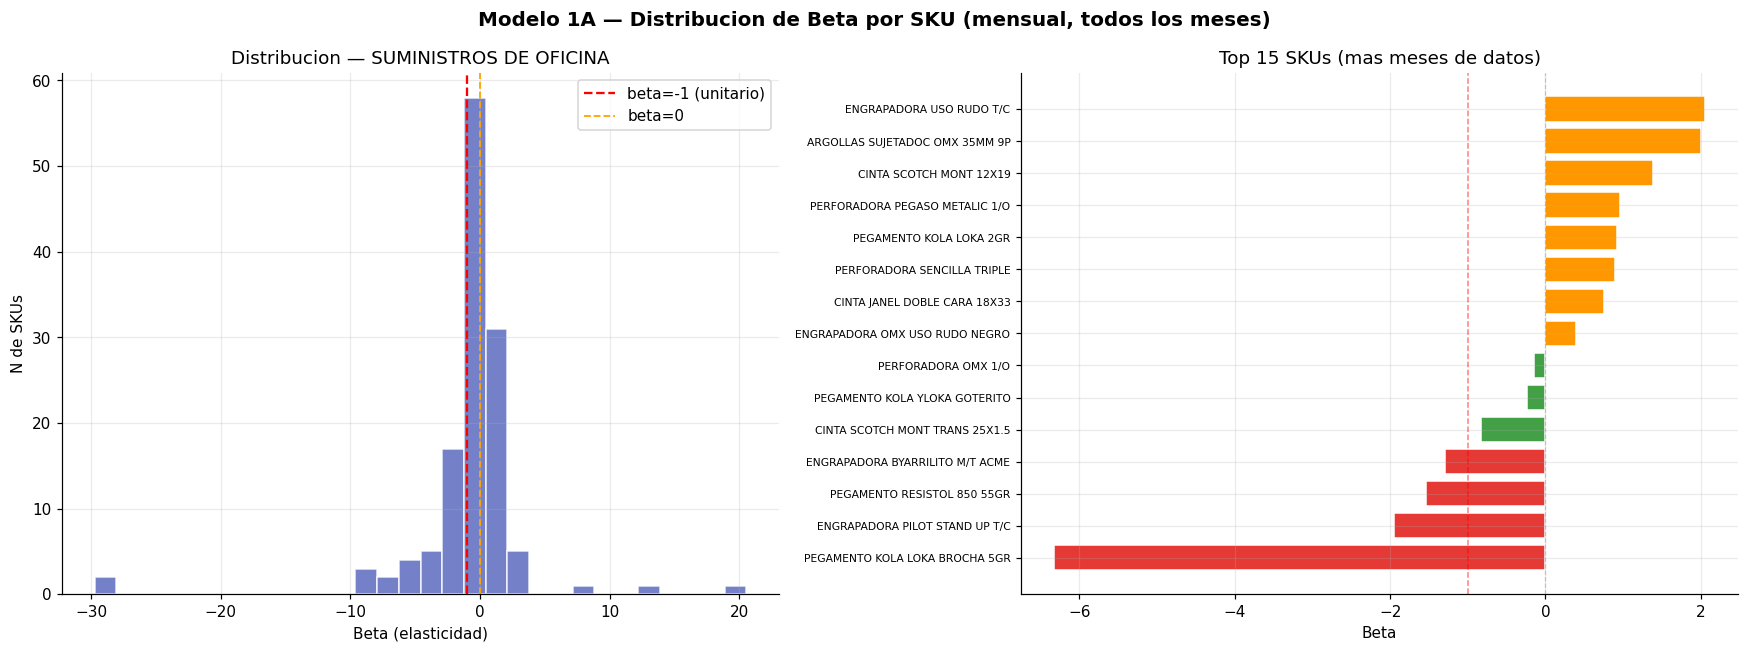

Mediana beta: -0.144  |  Rango: [-29.72, 20.57]


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Modelo 1A — Distribucion de Beta por SKU (mensual, todos los meses)", fontsize=13, fontweight="bold")

bv = df_mensual["beta"].dropna()
axes[0].hist(bv, bins=30, color="#5C6BC0", edgecolor="white", alpha=0.85)
axes[0].axvline(-1, color="red",    linestyle="--", lw=1.5, label="beta=-1 (unitario)")
axes[0].axvline( 0, color="orange", linestyle="--", lw=1.2, label="beta=0")
axes[0].set_xlabel("Beta (elasticidad)"); axes[0].set_ylabel("N de SKUs")
axes[0].set_title(f"Distribucion — {CATEGORIA}"); axes[0].legend()

top = df_mensual.nlargest(15, "n_meses").sort_values("beta")
cols = ["#E53935" if b < -1 else "#43A047" if b < 0 else "#FF9800" for b in top["beta"]]
axes[1].barh(range(len(top)), top["beta"], color=cols, edgecolor="white")
axes[1].set_yticks(range(len(top)))
axes[1].set_yticklabels(top["prod_nm"].str[:35], fontsize=7)
axes[1].axvline(-1, color="red",  linestyle="--", lw=1, alpha=0.5)
axes[1].axvline( 0, color="gray", linestyle="--", lw=0.8, alpha=0.4)
axes[1].set_xlabel("Beta"); axes[1].set_title("Top 15 SKUs (mas meses de datos)")
plt.tight_layout()
plt.show()
print(f"Mediana beta: {bv.median():.3f}  |  Rango: [{bv.min():.2f}, {bv.max():.2f}]")

---
## 3. Modelos 1B y 1C — Ventanas Rolling

**1B Trimestral:** ventana de 3 meses, avanzando 1 mes.
**1C Semestral:** ventana de 6 meses, avanzando 1 mes.

Permiten ver si la elasticidad *cambia en el tiempo* para cada SKU.
Filtros estrictos: CV >= 2%, |beta| <= 10.


In [4]:
betas_trim = []
for sku, grp in mensual.groupby("prod_nbr"):
    gi = grp.set_index("mes")
    for i in range(len(todos_meses) - 2):
        v = todos_meses[i:i+3]
        sub = gi[gi.index.isin(v)]
        r = ols_loglog(sub, min_cv=MIN_CV, min_r2=MIN_R2, max_beta=MAX_BETA)
        if r:
            betas_trim.append({"prod_nbr":sku, "prod_nm":grp["prod_nm"].iloc[0],
                                "mes_inicio":str(v[0]), "mes_fin":str(v[-1]),
                                "mes_fin_dt":v[-1].to_timestamp(), **r})
df_trim = pd.DataFrame(betas_trim)

betas_sem = []
for sku, grp in mensual.groupby("prod_nbr"):
    gi = grp.set_index("mes")
    for i in range(len(todos_meses) - 5):
        v = todos_meses[i:i+6]
        sub = gi[gi.index.isin(v)]
        r = ols_loglog(sub, min_cv=MIN_CV, min_r2=MIN_R2, max_beta=MAX_BETA)
        if r:
            betas_sem.append({"prod_nbr":sku, "prod_nm":grp["prod_nm"].iloc[0],
                               "mes_inicio":str(v[0]), "mes_fin":str(v[-1]),
                               "mes_fin_dt":v[-1].to_timestamp(), **r})
df_sem = pd.DataFrame(betas_sem)

print(f"Betas trimestrales validas : {len(df_trim):,}")
print(f"Betas semestrales validas  : {len(df_sem):,}")

Betas trimestrales validas : 187
Betas semestrales validas  : 433


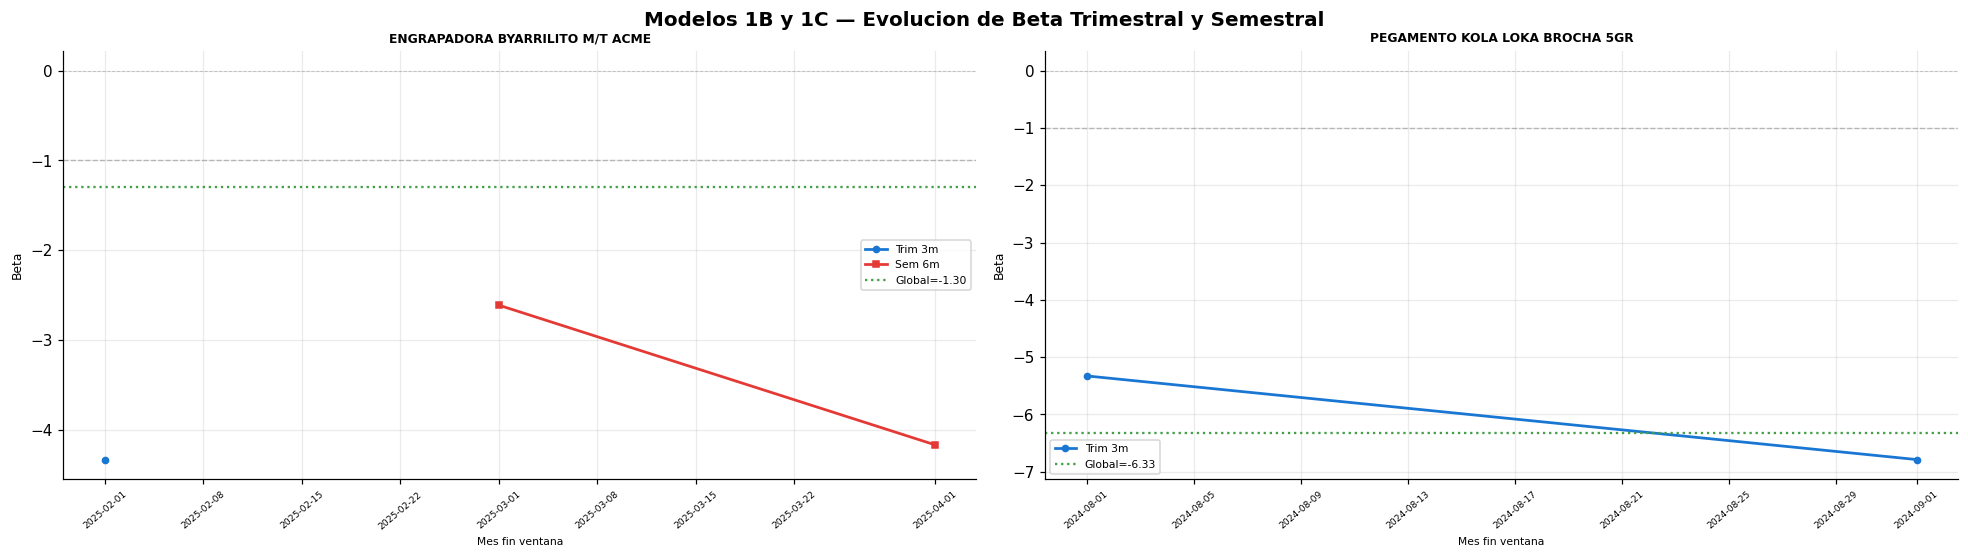

In [5]:
top_skus = (mensual.groupby("prod_nbr")["unidades"].sum()
            .sort_values(ascending=False).head(6).index.tolist())
skus_plot = [s for s in top_skus
             if s in df_trim["prod_nbr"].values or s in df_sem["prod_nbr"].values]

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle("Modelos 1B y 1C — Evolucion de Beta Trimestral y Semestral", fontsize=13, fontweight="bold")
axes_f = axes.flatten()

for idx, sku in enumerate(skus_plot[:6]):
    ax   = axes_f[idx]
    d3   = df_trim[df_trim["prod_nbr"]==sku].sort_values("mes_fin_dt")
    d6   = df_sem[df_sem["prod_nbr"]==sku].sort_values("mes_fin_dt")
    nm   = mensual.loc[mensual["prod_nbr"]==sku,"prod_nm"]
    nombre = str(nm.iloc[0])[:40] if len(nm)>0 else sku
    if len(d3)>0: ax.plot(d3["mes_fin_dt"], d3["beta"], "o-", ms=4, lw=1.8, color="#1976D2", label="Trim 3m")
    if len(d6)>0: ax.plot(d6["mes_fin_dt"], d6["beta"], "s-", ms=4, lw=1.8, color="#E53935", label="Sem 6m")
    bm = df_mensual.loc[df_mensual["prod_nbr"]==sku,"beta"]
    if len(bm)>0: ax.axhline(bm.iloc[0], color="#43A047", ls=":", lw=1.5, label=f"Global={bm.iloc[0]:.2f}")
    ax.axhline(-1, color="gray", ls="--", lw=0.9, alpha=0.5)
    ax.axhline( 0, color="gray", ls="--", lw=0.6, alpha=0.4)
    ax.set_title(f"{nombre}", fontsize=8, fontweight="bold")
    ax.set_xlabel("Mes fin ventana", fontsize=7); ax.set_ylabel("Beta", fontsize=8)
    ax.tick_params(axis="x", rotation=40, labelsize=6); ax.legend(fontsize=7); ax.grid(alpha=0.25)

for i in range(len(skus_plot), 6): axes_f[i].set_visible(False)
plt.tight_layout(); plt.show()

---
## 4. Modelo 2 — OLS Extendido

Incluye efectos fijos de **tienda**, **mes** y **subcategoria** (one-hot encoding),
mas un flag de **premium** (por keyword en nombre del producto).

$$\log(u+1) = \alpha + \beta\cdot\log(p) + \gamma\cdot\text{premium} + \delta_{\text{tienda}} + \omega_{\text{mes}} + \ldots$$

> La variable de promocion fue removida por no ser significativa (p=0.86).


In [6]:
agg2 = (carp.groupby(["prod_nbr","store_nbr","mes"])
        .agg(unidades=("qty","sum"), venta_tot=("venta_con_iva","sum"),
             es_premium=("es_premium","max"), margen=("margen","mean"),
             prod_nm=("prod_nm","first"), store_nm=("store_nm","first"),
             subdept_nm=("subdept_nm","first"))
        .reset_index())
agg2["precio"] = agg2["venta_tot"] / agg2["unidades"]
agg2 = agg2[agg2["precio"] > 0].copy()
agg2["log_u1"]  = np.log1p(agg2["unidades"])
agg2["log_p"]   = np.log(agg2["precio"])
agg2["mes_str"] = agg2["mes"].astype(str)

ohe_s = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")
ohe_m = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")
ohe_b = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")
se = ohe_s.fit_transform(agg2[["store_nbr"]])
me = ohe_m.fit_transform(agg2[["mes_str"]])
be = ohe_b.fit_transform(agg2[["subdept_nm"]].fillna("OTRO"))
sc = [f"store_{c}" for c in ohe_s.categories_[0][1:]]
mc = [f"mes_{c}"   for c in ohe_m.categories_[0][1:]]
bc = [f"sub_{i}"   for i in range(be.shape[1])]
df_se = pd.DataFrame(se, columns=sc, index=agg2.index)
df_me = pd.DataFrame(me, columns=mc, index=agg2.index)
df_be = pd.DataFrame(be, columns=bc, index=agg2.index)

X2 = add_constant(pd.concat([
    pd.DataFrame({"log_precio":agg2["log_p"].values, "es_premium":agg2["es_premium"].values,
                  "margen":agg2["margen"].fillna(0).values}, index=agg2.index),
    df_se, df_me, df_be], axis=1))
y2 = agg2["log_u1"].values
mask2 = np.isfinite(X2.values).all(axis=1) & np.isfinite(y2)
mod2 = OLS(y2[mask2], X2[mask2]).fit()

print(f"N obs: {int(mod2.nobs):,}  |  R2={mod2.rsquared:.4f}  R2adj={mod2.rsquared_adj:.4f}")
print(f"Beta log_precio : {mod2.params['log_precio']:.4f}  (p={mod2.pvalues['log_precio']:.4f})")
print(f"Coef premium    : {mod2.params['es_premium']:.4f}  (p={mod2.pvalues['es_premium']:.4f})")
print(f"Coef margen     : {mod2.params['margen']:.4f}      (p={mod2.pvalues['margen']:.4f})")

N obs: 6,544  |  R2=0.0361  R2adj=0.0179
Beta log_precio : -0.0413  (p=0.0000)
Coef premium    : -0.0809  (p=0.6334)
Coef margen     : 0.0525      (p=0.2743)


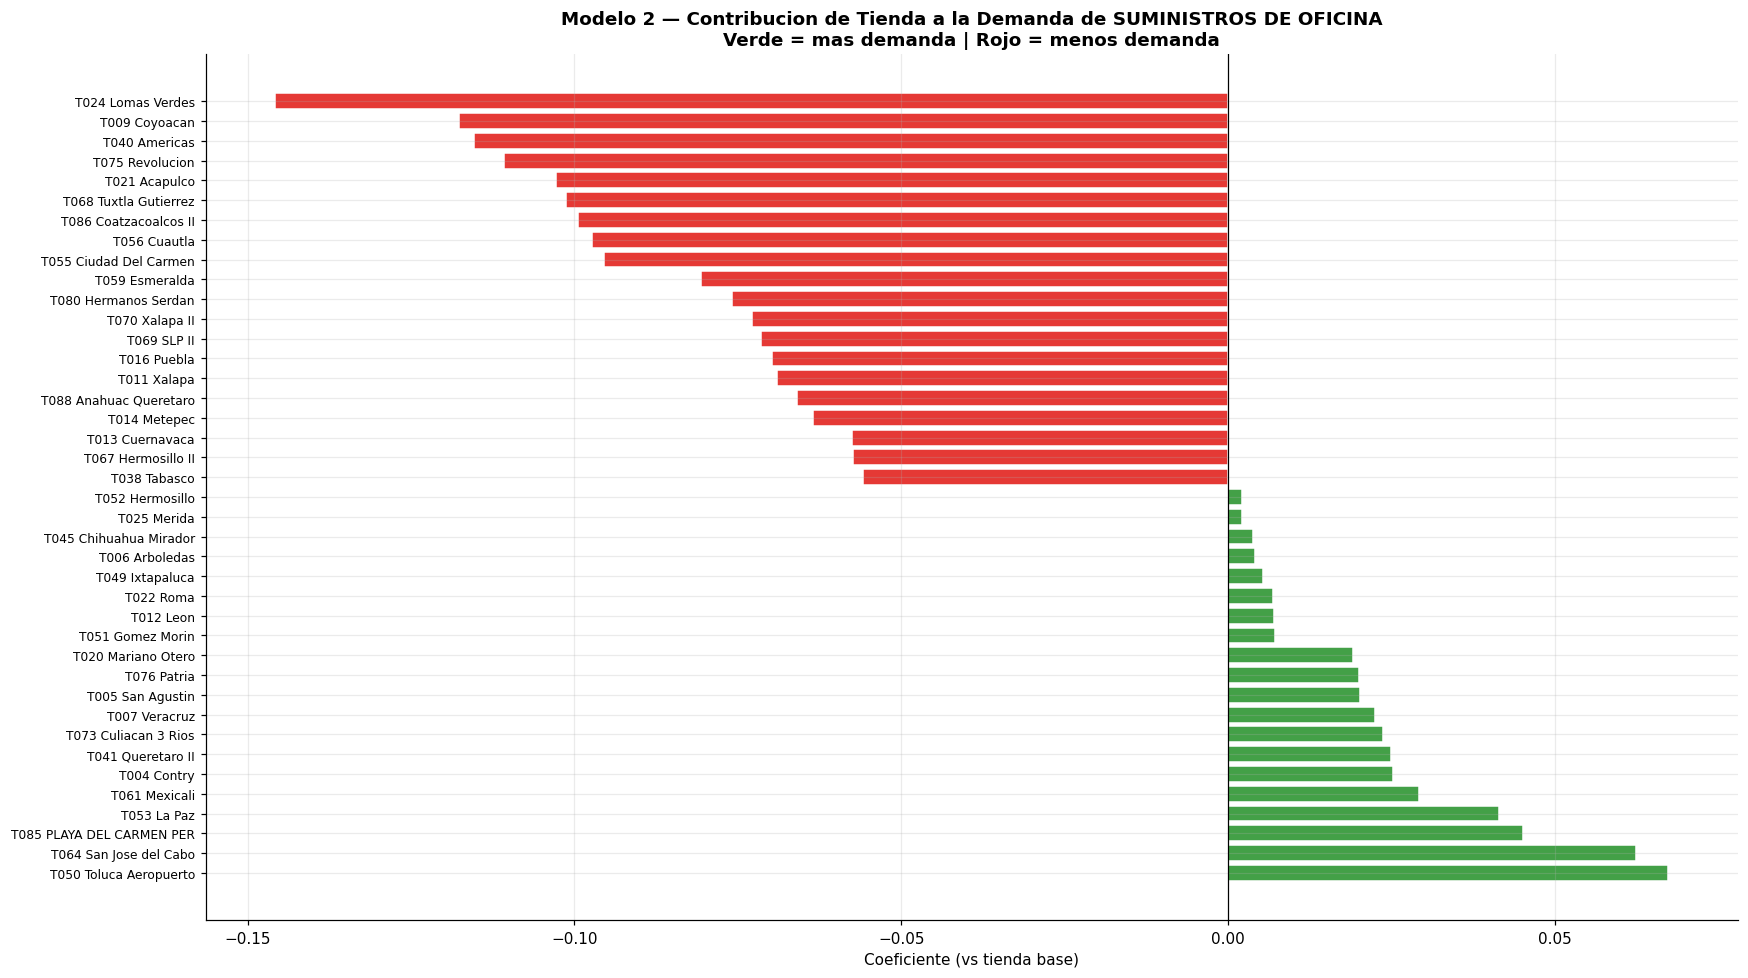

In [7]:
# Coeficientes de tienda
store_coef = pd.DataFrame({
    "store_nbr": ohe_s.categories_[0][1:],
    "coef":      mod2.params[sc].values.round(4),
    "pval":      mod2.pvalues[sc].values.round(4),
}).sort_values("coef", ascending=False)
sn = agg2[["store_nbr","store_nm"]].drop_duplicates()
store_coef = store_coef.merge(sn, on="store_nbr", how="left")

n_show = min(40, len(store_coef))
show   = pd.concat([store_coef.head(n_show//2), store_coef.tail(n_show//2)]).drop_duplicates()
fig, ax = plt.subplots(figsize=(16, 9))
cols_bar = ["#43A047" if c >= 0 else "#E53935" for c in show["coef"]]
labels   = show.apply(lambda r: f"{r['store_nbr']} {str(r['store_nm']).strip()[:20]}", axis=1)
ax.barh(range(len(show)), show["coef"].values, color=cols_bar, edgecolor="white")
ax.set_yticks(range(len(show))); ax.set_yticklabels(labels, fontsize=8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Coeficiente (vs tienda base)")
ax.set_title(f"Modelo 2 — Contribucion de Tienda a la Demanda de {CATEGORIA}\n"
             "Verde = mas demanda | Rojo = menos demanda", fontweight="bold")
plt.tight_layout(); plt.show()

---
## 5. Simulador de Elasticidad

Para 4 SKUs seleccionados (distintos niveles de elasticidad), se simulan 5 escenarios:
**-10%, -5%, 0% (Base), +5%, +10%** de cambio en el precio. Se calcula el impacto en:
- **Unidades vendidas** (Formula 1): $u_1 = u_0 \cdot (1 + \Delta p)^{\beta}$
- **Ingreso** (Formula 2): $I_1 = p_1 \cdot u_1$
- **Margen** (Formula 3): $M_1 = (p_1 - c) \cdot u_1$


In [8]:
NOMBRES_SIM = [
    "IMANES STUK SUMMER 6PZ",
    "ENGRAPADORA BYARRILITO M/T ACME",
    "CINTA SCOTCH MAGICA 18X33",
    "PERFORADORA MAPED 12HJS 2/O",
]
CAMBIOS   = [-0.10, -0.05, 0.00, 0.05, 0.10]
ETIQUETAS = ["-10%", "-5%", "0% (Base)", "+5%", "+10%"]
COLORES   = ["#2E7D32", "#81C784", "#9E9E9E", "#EF9A9A", "#C62828"]

sim_base = df_mensual[df_mensual["prod_nm"].isin(NOMBRES_SIM)][
    ["prod_nbr","prod_nm","beta"]].drop_duplicates("prod_nm")
base_stats = (mensual.groupby("prod_nbr")
              .agg(precio_base=("precio","mean"), unidades_base=("unidades","mean"))
              .reset_index())
sim_base = sim_base.merge(base_stats, on="prod_nbr", how="left")

ventas_c = pd.read_csv(find(BASE,"Ventas_OfficeMax.csv"), encoding="latin-1", low_memory=False)
ventas_c["prod_nbr"]   = ventas_c["prod_nbr"].astype(str).str.strip()
ventas_c["qty"]        = pd.to_numeric(ventas_c["qty"],   errors="coerce")
ventas_c["costo"]      = pd.to_numeric(ventas_c["costo"], errors="coerce")
ventas_c               = ventas_c[(ventas_c["qty"]>0) & (ventas_c["costo"]>0)]
ventas_c["costo_unit"] = ventas_c["costo"] / ventas_c["qty"]
costo_prom = ventas_c.groupby("prod_nbr")["costo_unit"].mean().reset_index()
sim_base = sim_base.merge(costo_prom, on="prod_nbr", how="left")

sim_rows = []
for _, row in sim_base.iterrows():
    p0 = row["precio_base"]; u0 = row["unidades_base"]
    beta = row["beta"];       c0 = row["costo_unit"] if pd.notna(row["costo_unit"]) else 0
    rev0 = p0*u0; marg0 = (p0-c0)*u0
    for cambio, etiq in zip(CAMBIOS, ETIQUETAS):
        p1 = p0*(1+cambio); u1 = u0*(1+cambio)**beta
        ing1 = p1*u1;        marg1 = (p1-c0)*u1
        sim_rows.append({
            "sku":str(row["prod_nm"])[:30], "beta":round(beta,4),
            "costo_unitario":round(c0,2), "precio_base":round(p0,2),
            "unidades_base":round(u0,1),   "ingreso_base":round(rev0,2),
            "margen_base":round(marg0,2),  "cambio_precio":etiq,
            "precio_nuevo":round(p1,2),    "unidades_sim":round(u1,1),
            "ingreso_simulado":round(ing1,2), "margen_simulado":round(marg1,2),
            "delta_unidades":round(u1-u0,1),
            "delta_ingreso_pct":round((ing1-rev0)/rev0*100,1),
            "delta_margen_pct":round((marg1-marg0)/marg0*100,1) if marg0!=0 else 0,
        })
df_sim = pd.DataFrame(sim_rows)
df_sim[["sku","cambio_precio","precio_nuevo","unidades_sim",
        "delta_unidades","ingreso_simulado","delta_ingreso_pct",
        "margen_simulado","delta_margen_pct"]]

,sku,cambio_precio,precio_nuevo,unidades_sim,delta_unidades,ingreso_simulado,delta_ingreso_pct,margen_simulado,delta_margen_pct
0,CINTA SCOTCH MAGICA 18X33,-10%,77.07,8.6,1.5,661.88,9.8,147.96,-18.5
1,CINTA SCOTCH MAGICA 18X33,-5%,81.35,7.8,0.7,630.85,4.7,166.80,-8.1
2,CINTA SCOTCH MAGICA 18X33,0% (Base),85.64,7.0,0.0,602.75,0.0,181.54,0.0
3,CINTA SCOTCH MAGICA 18X33,+5%,89.92,6.4,-0.6,577.18,-4.2,193.04,6.3
4,CINTA SCOTCH MAGICA 18X33,+10%,94.20,5.9,-1.2,553.82,-8.1,201.98,11.3
5,ENGRAPADORA BYARRILITO M/T ACM,-10%,92.41,14.0,1.8,1298.11,3.2,326.60,-20.5
6,ENGRAPADORA BYARRILITO M/T ACM,-5%,97.55,13.1,0.8,1277.30,1.5,371.68,-9.5
7,ENGRAPADORA BYARRILITO M/T ACM,0% (Base),102.68,12.2,0.0,1257.87,0.0,410.62,0.0
8,ENGRAPADORA BYARRILITO M/T ACM,+5%,107.82,11.5,-0.8,1239.66,-1.4,444.43,8.2
9,ENGRAPADORA BYARRILITO M/T ACM,+10%,112.95,10.8,-1.4,1222.54,-2.8,473.94,15.4


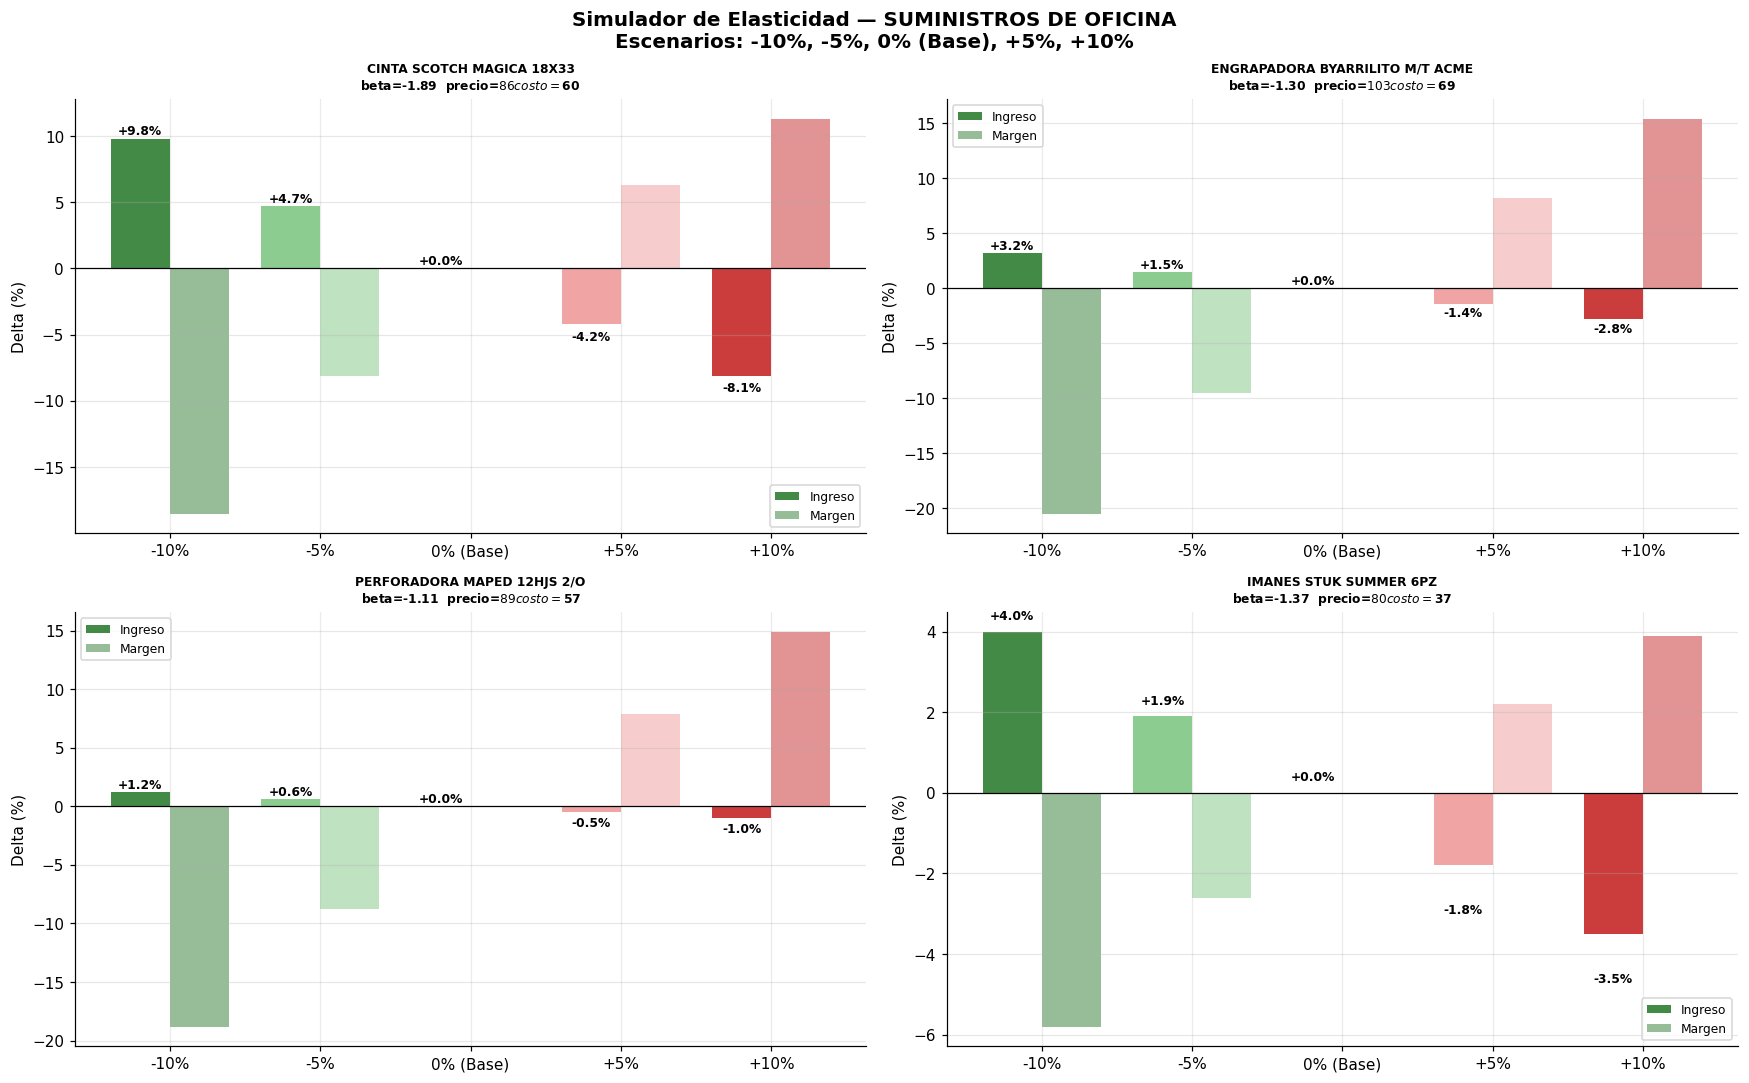

In [9]:
nombres_sim = sim_base["prod_nm"].tolist()
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f"Simulador de Elasticidad — {CATEGORIA}\nEscenarios: -10%, -5%, 0% (Base), +5%, +10%",
             fontsize=13, fontweight="bold")

for idx, nombre in enumerate(nombres_sim):
    ax  = axes[idx//2][idx%2]
    sub = df_sim[df_sim["sku"]==str(nombre)[:30]]
    p0  = sub["precio_base"].iloc[0]; u0 = sub["unidades_base"].iloc[0]
    beta= sub["beta"].iloc[0];        c0 = sub["costo_unitario"].iloc[0]
    x2  = np.arange(len(CAMBIOS))*1.4; w = 0.55
    b_i = ax.bar(x2-w/2, sub["delta_ingreso_pct"].values, w, color=COLORES, alpha=0.9, label="Ingreso")
    b_m = ax.bar(x2+w/2, sub["delta_margen_pct"].values,  w, color=COLORES, alpha=0.5, label="Margen")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x2); ax.set_xticklabels(ETIQUETAS, fontsize=10)
    ax.set_ylabel("Delta (%)"); ax.set_title(f"{nombre}\nbeta={beta:.2f}  precio=${p0:.0f}  costo=${c0:.0f}", fontsize=8, fontweight="bold")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
    for bar, row in zip(b_i, sub.itertuples()):
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+(0.3 if h>=0 else -1.2),
                f"{row.delta_ingreso_pct:+.1f}%", ha="center", fontsize=8, fontweight="bold")
plt.tight_layout(); plt.show()

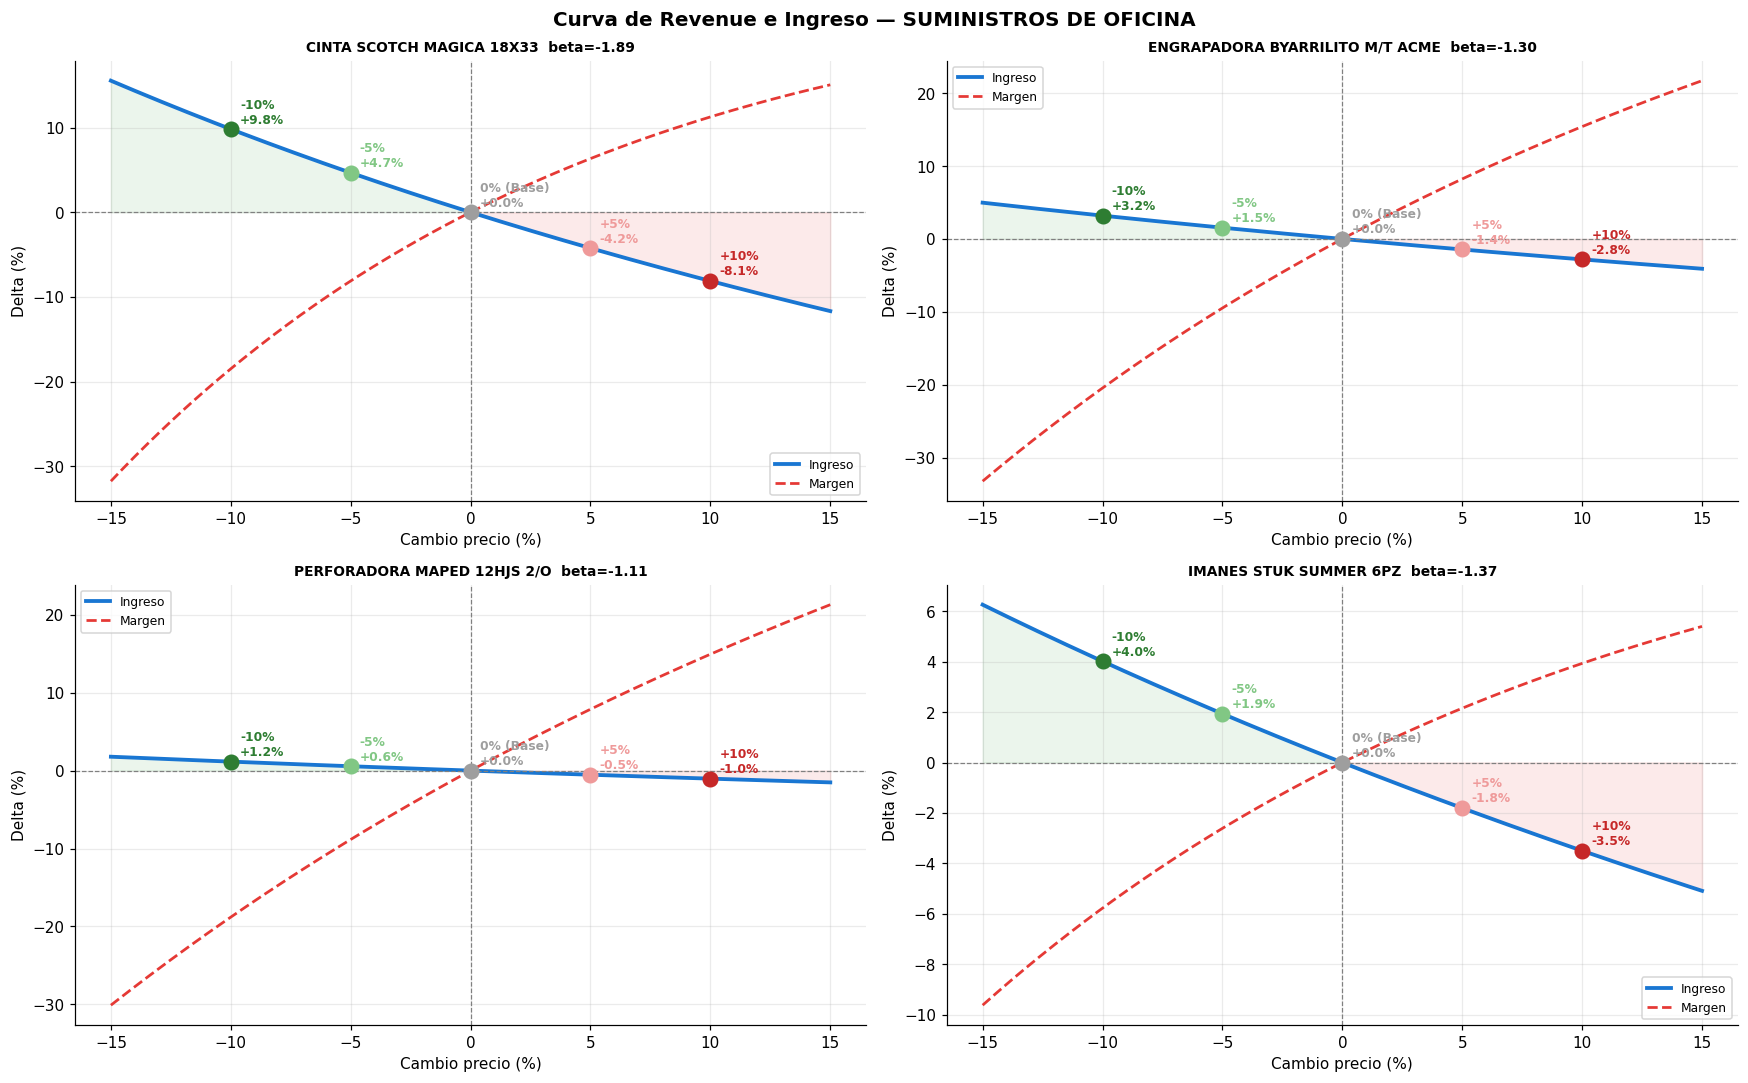

In [10]:
cambios_cont = np.linspace(-0.15, 0.15, 300)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f"Curva de Revenue e Ingreso — {CATEGORIA}", fontsize=13, fontweight="bold")

for idx, nombre in enumerate(nombres_sim):
    ax   = axes[idx//2][idx%2]
    sub  = df_sim[df_sim["sku"]==str(nombre)[:30]]
    p0   = sub["precio_base"].iloc[0]; u0 = sub["unidades_base"].iloc[0]
    beta = sub["beta"].iloc[0];        c0 = sub["costo_unitario"].iloc[0]
    rev0 = p0*u0; marg0 = (p0-c0)*u0
    pct_i = [(p0*(1+c)*u0*(1+c)**beta - rev0)/rev0*100 for c in cambios_cont]
    pct_m = [((p0*(1+c)-c0)*u0*(1+c)**beta - marg0)/marg0*100 if marg0!=0 else 0 for c in cambios_cont]
    ax.plot(cambios_cont*100, pct_i, color="#1976D2", lw=2.5, label="Ingreso")
    ax.plot(cambios_cont*100, pct_m, color="#E53935", lw=1.8, ls="--", label="Margen")
    ax.axhline(0, color="gray", ls="--", lw=0.8); ax.axvline(0, color="gray", ls="--", lw=0.8)
    ax.fill_between(cambios_cont*100, pct_i, 0, where=[p>=0 for p in pct_i], alpha=0.1, color="#43A047")
    ax.fill_between(cambios_cont*100, pct_i, 0, where=[p<0  for p in pct_i], alpha=0.1, color="#E53935")
    for cambio, etiq, col in zip(CAMBIOS, ETIQUETAS, COLORES):
        dp = (p0*(1+cambio)*u0*(1+cambio)**beta - rev0)/rev0*100
        ax.scatter(cambio*100, dp, color=col, s=90, zorder=5)
        ax.annotate(f"{etiq}\n{dp:+.1f}%", (cambio*100, dp), textcoords="offset points",
                    xytext=(6,4), fontsize=8, color=col, fontweight="bold")
    ax.set_xlabel("Cambio precio (%)"); ax.set_ylabel("Delta (%)")
    ax.set_title(f"{nombre}  beta={beta:.2f}", fontsize=9, fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

---
## 6. Recomendaciones Finales por SKU

Clasificacion basada en el **beta mensual global** (M1A):

| Criterio | Categoria |
|---|---|
| beta in (-1, 0), p<0.10, n>=6 | **SUBIR PRECIO** |
| beta in (-1.5, -1], p<0.10, n>=6 | **MANTENER PRECIO** |
| beta < -1.5, p<0.10, n>=6 | **BAJAR / PROMOVER** |
| resto | No recomendable |


In [11]:
sku_info = (carp.groupby(["prod_nbr","prod_nm","subdept_nm","tipo_marca"])
            .agg(unidades_tot=("qty","sum"), precio_prom=("precio_tx","mean"),
                 margen_prom=("margen","mean"), n_tiendas=("store_nbr","nunique"),
                 n_meses=("mes","nunique"), es_premium=("es_premium","max"))
            .reset_index().sort_values("unidades_tot", ascending=False))
rec = df_mensual.merge(
    sku_info[["prod_nbr","unidades_tot","precio_prom","margen_prom","n_tiendas"]],
    on="prod_nbr", how="left")

def clasificar(row):
    b, p, n = row["beta"], row["pval"], row["n_meses"]
    if p >= 0.10 or n < 6 or abs(b) > 3 or b > 0: return "NO RECOMENDABLE"
    if -1 < b < 0:      return "SUBIR PRECIO"
    if -1.5 <= b <= -1: return "MANTENER PRECIO"
    return "BAJAR / PROMOVER"

def razon(row):
    b, p, n, cat = row["beta"], row["pval"], row["n_meses"], row["recomendacion"]
    if cat == "NO RECOMENDABLE":
        if p >= 0.10: return f"Beta no significativa (p={p:.2f})"
        if n < 6:     return f"Solo {n} meses de datos"
        if b > 0:     return "Beta positiva (anomalia)"
        return f"|beta|={abs(b):.1f} fuera de rango creible"
    if cat == "SUBIR PRECIO":    return f"Inelastica (beta={b:.2f})"
    if cat == "MANTENER PRECIO": return f"Cerca de unitaria (beta={b:.2f})"
    return f"Elastica (beta={b:.2f}): bajar 10% -> +{abs(b)*10:.1f}% unidades"

rec["recomendacion"] = rec.apply(clasificar, axis=1)
rec["razon"]         = rec.apply(razon, axis=1)
orden = {"SUBIR PRECIO":0,"MANTENER PRECIO":1,"BAJAR / PROMOVER":2,"NO RECOMENDABLE":3}
rec["_ord"] = rec["recomendacion"].map(orden)
rec = rec.sort_values(["_ord","beta"], ascending=[True,False]).drop("_ord", axis=1)

for cat in ["SUBIR PRECIO","MANTENER PRECIO","BAJAR / PROMOVER","NO RECOMENDABLE"]:
    sub = rec[rec["recomendacion"]==cat]
    print(f"\n--- {cat} ({len(sub)} SKUs) ---")
    if cat != "NO RECOMENDABLE":
        print(sub[["prod_nm","subdept_nm","beta","pval","n_meses","recomendacion","razon"]].to_string(index=False))


--- SUBIR PRECIO (0 SKUs) ---
Empty DataFrame
Columns: [prod_nm, subdept_nm, beta, pval, n_meses, recomendacion, razon]
Index: []

--- MANTENER PRECIO (5 SKUs) ---
                        prod_nm           subdept_nm    beta   pval  n_meses   recomendacion                          razon
  IMANES DE CORCHO ECO STUK 6PZ     SUJETADOCUMENTOS -1.0049 0.0172        9 MANTENER PRECIO Cerca de unitaria (beta=-1.00)
    PERFORADORA MAPED 12HJS 2/O         PERFORADORAS -1.1089 0.0846       19 MANTENER PRECIO Cerca de unitaria (beta=-1.11)
ENGRAPADORA BYARRILITO M/T ACME         ENGRAPADORAS -1.2989 0.0553       28 MANTENER PRECIO Cerca de unitaria (beta=-1.30)
         IMANES STUK SUMMER 6PZ     SUJETADOCUMENTOS -1.3735 0.0002       15 MANTENER PRECIO Cerca de unitaria (beta=-1.37)
 CINTA SUJ VELCRO NG 90X1.9 1PZ ARTICULOS DE MONTAJE -1.4151 0.0679       14 MANTENER PRECIO Cerca de unitaria (beta=-1.42)

--- BAJAR / PROMOVER (3 SKUs) ---
                              prod_nm       subdept_nm  

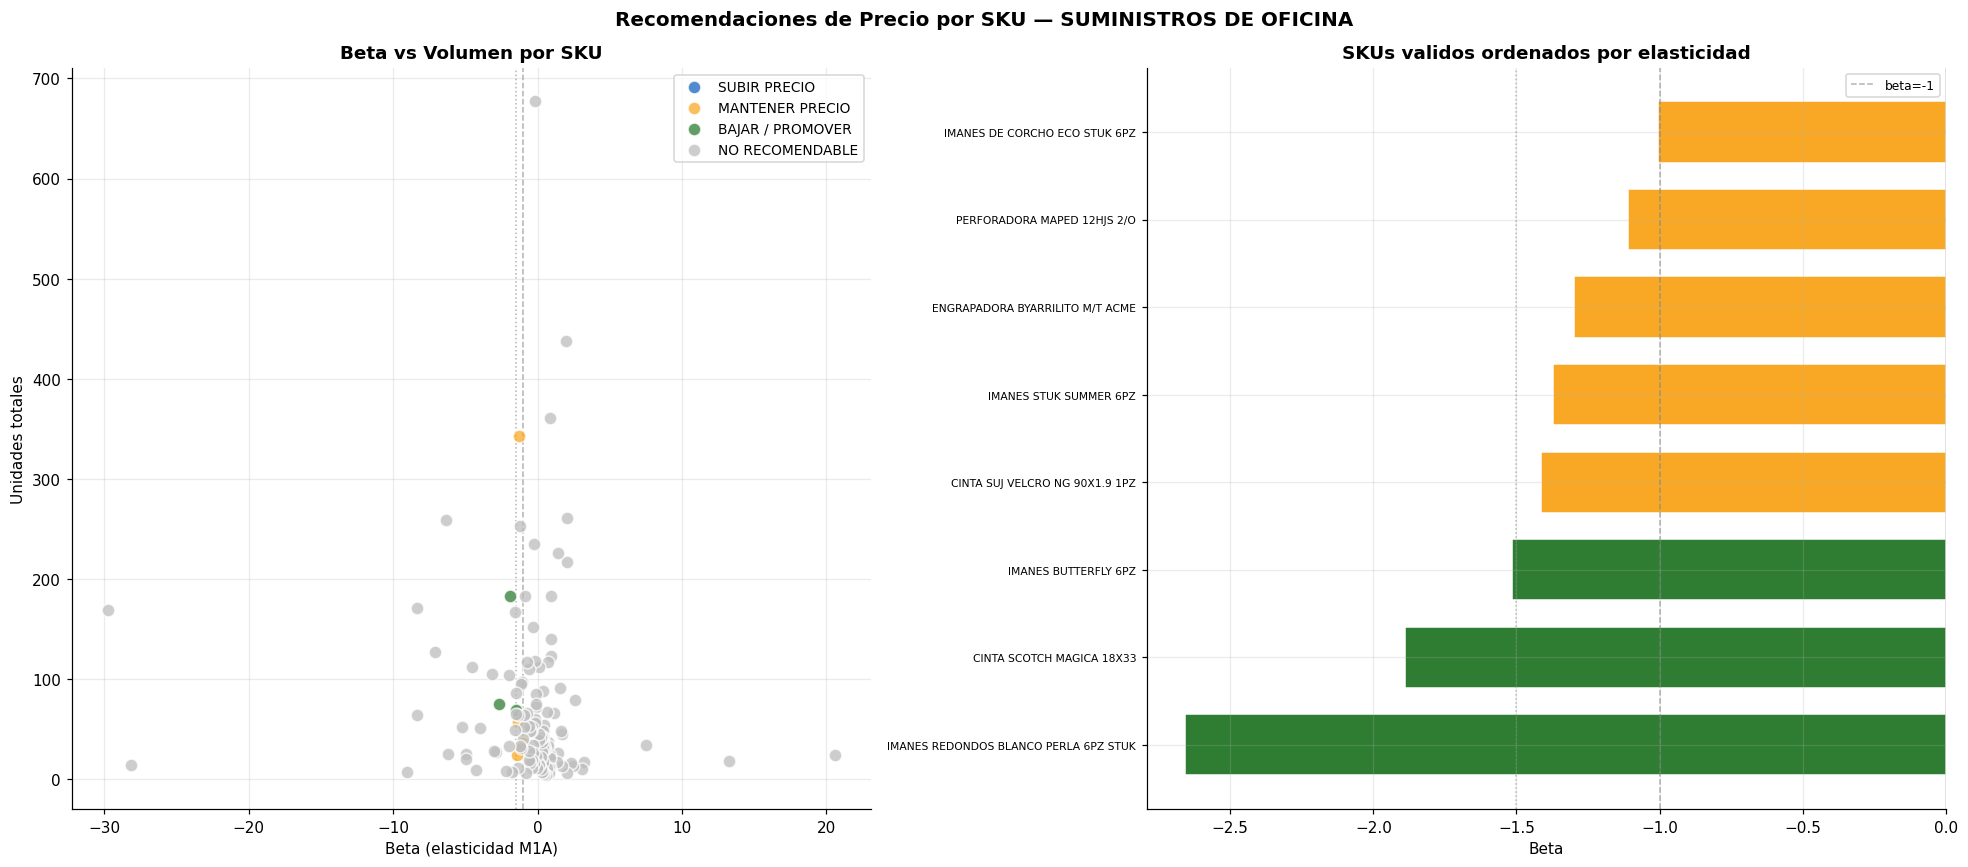

In [12]:
COLORES_CAT = {"SUBIR PRECIO":"#1565C0","MANTENER PRECIO":"#F9A825",
               "BAJAR / PROMOVER":"#2E7D32","NO RECOMENDABLE":"#BDBDBD"}
validos = rec[rec["recomendacion"] != "NO RECOMENDABLE"].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(f"Recomendaciones de Precio por SKU — {CATEGORIA}", fontsize=13, fontweight="bold")

ax = axes[0]
for cat, color in COLORES_CAT.items():
    s = rec[rec["recomendacion"]==cat]
    ax.scatter(s["beta"], s["unidades_tot"], color=color, alpha=0.75, s=70,
               label=cat, edgecolors="white", zorder=3)
ax.axvline(-1, color="gray", lw=1, ls="--", alpha=0.6)
ax.axvline(-1.5, color="gray", lw=1, ls=":", alpha=0.6)
ax.set_xlabel("Beta (elasticidad M1A)"); ax.set_ylabel("Unidades totales")
ax.set_title("Beta vs Volumen por SKU", fontweight="bold"); ax.legend(fontsize=9)

ax2 = axes[1]
vp = validos.sort_values("beta")
ax2.barh(range(len(vp)), vp["beta"],
         color=[COLORES_CAT[c] for c in vp["recomendacion"]], edgecolor="white", height=0.7)
ax2.axvline(-1,   color="gray", lw=1, ls="--", alpha=0.6, label="beta=-1")
ax2.axvline(-1.5, color="gray", lw=1, ls=":",  alpha=0.5)
ax2.axvline(0,    color="black", lw=0.8)
ax2.set_yticks(range(len(vp))); ax2.set_yticklabels(vp["prod_nm"].str[:40], fontsize=7)
ax2.set_xlabel("Beta"); ax2.set_title("SKUs validos ordenados por elasticidad", fontweight="bold")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 7. Calendario Mensual de Accion + Heatmap

Cada ventana rolling vota los meses que cubre segun su beta:
- beta > -1.0 -> **SUBIR** (inelastico)
- -1.5 < beta <= -1.0 -> **MANTENER**
- beta <= -1.5 -> **PROMOVER**

Ventanas con p < 0.10 pesan doble.
Solo se asigna accion si un tipo domina >50% de votos.


In [13]:
MONTH_NAMES = {1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun",
               7:"Jul",8:"Ago",9:"Sep",10:"Oct",11:"Nov",12:"Dic"}
UMBRAL_SUBIR = -1.0
UMBRAL_MANT  = -1.5

def meses_ventana(inicio, fin):
    p = pd.Period(inicio, freq="M"); e = pd.Period(fin, freq="M"); ms = []
    while p <= e: ms.append(p.month); p += 1
    return ms

skus_rolling = sorted(set(df_sem["prod_nbr"].unique()) | set(df_trim["prod_nbr"].unique()))
cal_rows = []
for sku in skus_rolling:
    nm = mensual.loc[mensual["prod_nbr"]==sku, "prod_nm"]
    nombre_sku = nm.iloc[0] if len(nm) > 0 else sku
    d_all = pd.concat([df_sem[df_sem["prod_nbr"]==sku].assign(tipo="sem"),
                        df_trim[df_trim["prod_nbr"]==sku].assign(tipo="trim")], ignore_index=True)
    d_all = d_all[d_all["pval"] < 0.25]
    if len(d_all) == 0: continue
    mv = {m:{"subir":0,"mantener":0,"promover":0,"n":0} for m in range(1,13)}
    for _, vrow in d_all.iterrows():
        b, p = vrow["beta"], vrow["pval"]; peso = 2 if p < 0.10 else 1
        for m in meses_ventana(str(vrow["mes_inicio"]), str(vrow["mes_fin"])):
            mv[m]["n"] += 1
            if b > UMBRAL_SUBIR: mv[m]["subir"] += peso
            elif b > UMBRAL_MANT: mv[m]["mantener"] += peso
            else: mv[m]["promover"] += peso
    for mes in range(1,13):
        v = mv[mes]; total = v["subir"]+v["mantener"]+v["promover"]
        if v["n"] == 0: accion = "Sin datos"
        else:
            best = max(["subir","mantener","promover"], key=lambda k: v[k])
            accion = {"subir":"SUBIR","mantener":"MANTENER","promover":"PROMOVER"}[best] if v[best]/total > 0.50 else "Sin patron"
        cal_rows.append({"prod_nbr":sku,"prod_nm":nombre_sku,"mes_num":mes,
                         "mes_nm":MONTH_NAMES[mes],"votos_subir":v["subir"],
                         "votos_mantener":v["mantener"],"votos_promover":v["promover"],
                         "n_ventanas":v["n"],"accion":accion})
df_cal = pd.DataFrame(cal_rows)
print(f"SKUs con patron definido en al menos un mes: {df_cal[df_cal['accion'].isin(['SUBIR','MANTENER','PROMOVER'])]['prod_nbr'].nunique()}")

SKUs con patron definido en al menos un mes: 52


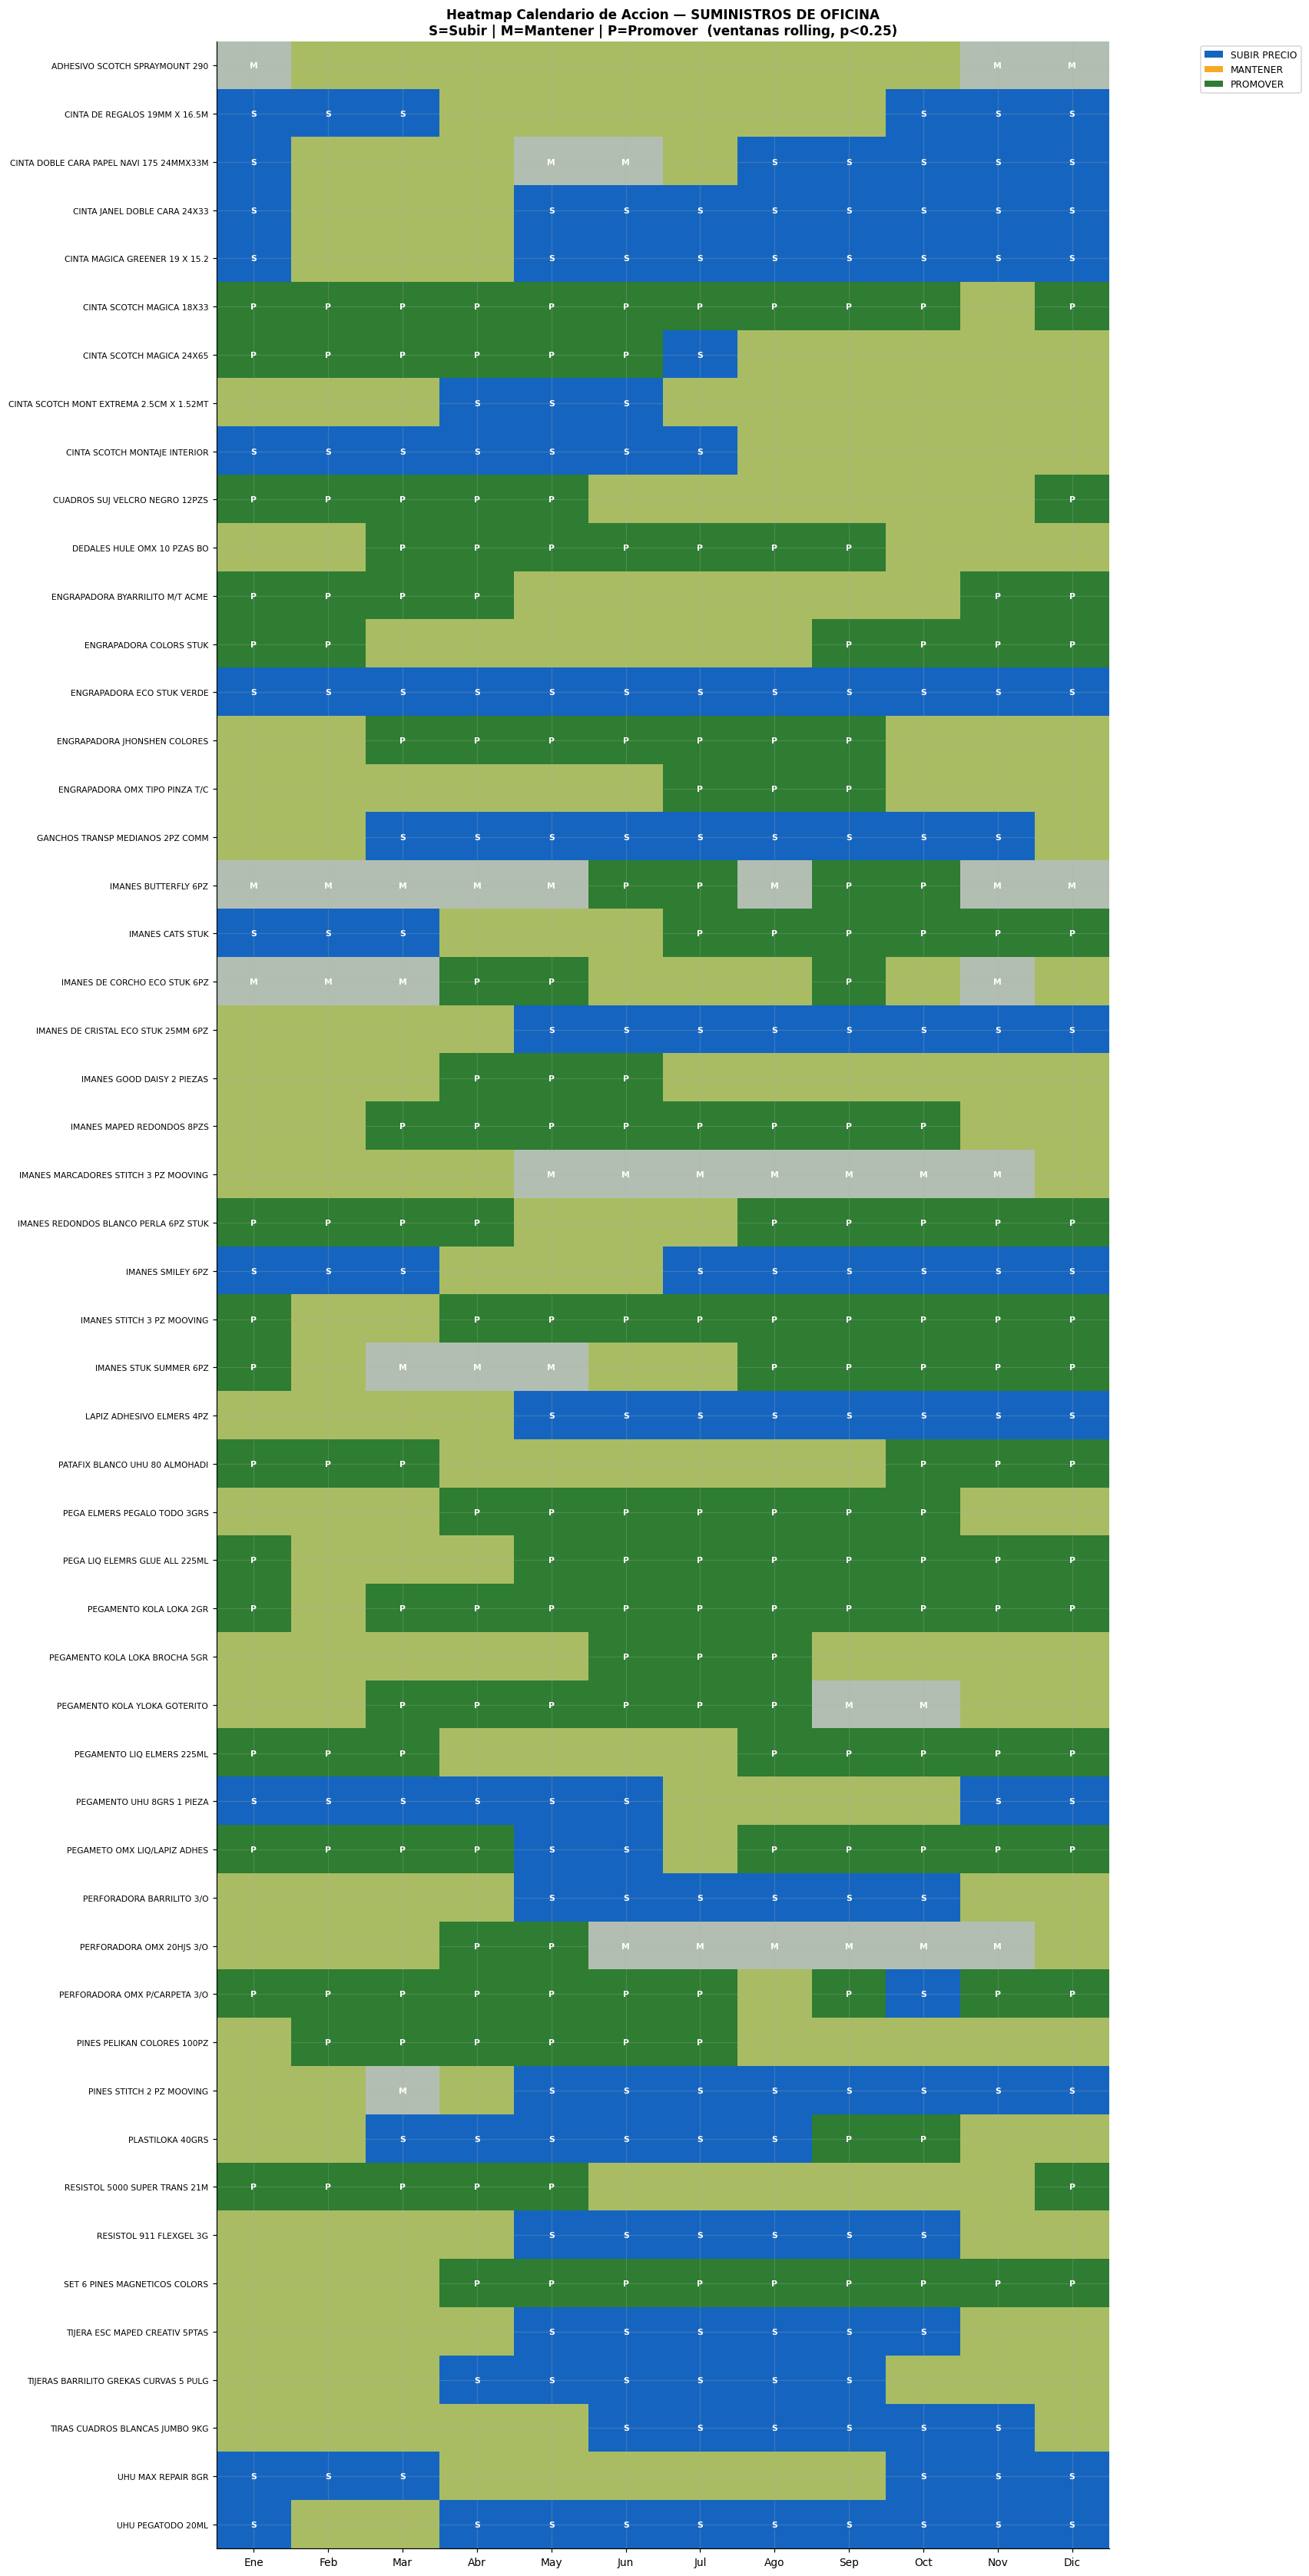

In [14]:
ACCION_NUM = {"SUBIR":2,"MANTENER":1,"PROMOVER":-1,"Sin patron":0,"Sin datos":0}
skus_heat = [s for s in skus_rolling
             if df_cal[(df_cal["prod_nbr"]==s) & df_cal["accion"].isin(["SUBIR","MANTENER","PROMOVER"])].shape[0] >= 3]

pivot = (df_cal[df_cal["prod_nbr"].isin(skus_heat)]
         .pivot(index="prod_nm", columns="mes_num", values="accion")
         .reindex(columns=range(1,13)))
pivot_num = pivot.map(lambda x: ACCION_NUM.get(x,0) if pd.notna(x) else 0)

fig, ax = plt.subplots(figsize=(16, max(6, len(skus_heat)*0.55+2)))
cmap = plt.cm.colors.LinearSegmentedColormap.from_list("cal",
    ["#2E7D32","#81C784","#F9A825","#90CAF9","#1565C0"], N=256)
ax.imshow(pivot_num.values.astype(float), aspect="auto", cmap=cmap, vmin=-1, vmax=2)
ax.set_xticks(range(12)); ax.set_xticklabels([MONTH_NAMES[m] for m in range(1,13)], fontsize=9)
ax.set_yticks(range(len(pivot_num))); ax.set_yticklabels(pivot_num.index.str[:45], fontsize=7)
for i in range(len(pivot_num)):
    for j in range(12):
        etiq = {"SUBIR":"S","MANTENER":"M","PROMOVER":"P"}.get(pivot.iloc[i,j] if pd.notna(pivot.iloc[i,j]) else "","")
        if etiq: ax.text(j, i, etiq, ha="center", va="center", fontsize=7, fontweight="bold", color="white")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="#1565C0",label="SUBIR PRECIO"),
                   Patch(facecolor="#F9A825",label="MANTENER"),
                   Patch(facecolor="#2E7D32",label="PROMOVER")],
          loc="upper right", bbox_to_anchor=(1.22,1), fontsize=8)
ax.set_title(f"Heatmap Calendario de Accion — {CATEGORIA}\nS=Subir | M=Mantener | P=Promover  (ventanas rolling, p<0.25)", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

---
## 8. Casos Inelasticos en Ventanas Rolling

SKUs donde algun periodo semestral o trimestral muestra beta en (-1, 0)
con significancia estadistica (p < 0.10).

> Estos son los candidatos mas solidos para subir precio: la demanda es
> relativamente insensible al precio en ese periodo.


In [15]:
PVAL_CORTE = 0.10
inel_sem  = df_sem[(df_sem["beta"]>-1)  & (df_sem["beta"]<0)  & (df_sem["pval"]<PVAL_CORTE)].copy()
inel_trim = df_trim[(df_trim["beta"]>-1) & (df_trim["beta"]<0) & (df_trim["pval"]<PVAL_CORTE)].copy()

if len(inel_sem) > 0:
    print(f"Semestral — {len(inel_sem)} ventanas, {inel_sem['prod_nbr'].nunique()} SKUs:")
    print(inel_sem[["prod_nm","mes_inicio","mes_fin","beta","r2","pval"]].to_string(index=False))
if len(inel_trim) > 0:
    print(f"\nTrimestral — {len(inel_trim)} ventanas, {inel_trim['prod_nbr'].nunique()} SKUs:")
    print(inel_trim[["prod_nm","mes_inicio","mes_fin","beta","r2","pval"]].to_string(index=False))

Semestral — 7 ventanas, 3 SKUs:
                      prod_nm mes_inicio mes_fin    beta     r2   pval
CINTA SCOTCH MONTAJE INTERIOR    2025-02 2025-07 -0.8846 0.5361 0.0980
   ENGRAPADORA ECO STUK VERDE    2024-11 2025-04 -0.1868 0.8107 0.0372
   ENGRAPADORA ECO STUK VERDE    2024-12 2025-05 -0.1986 0.9567 0.0219
   ENGRAPADORA ECO STUK VERDE    2025-01 2025-06 -0.1929 0.9973 0.0334
    PINES STITCH 2 PZ MOOVING    2025-04 2025-09 -0.8024 0.9091 0.0465
    PINES STITCH 2 PZ MOOVING    2025-05 2025-10 -0.8024 0.9091 0.0465
    PINES STITCH 2 PZ MOOVING    2025-06 2025-11 -0.8024 0.9091 0.0465


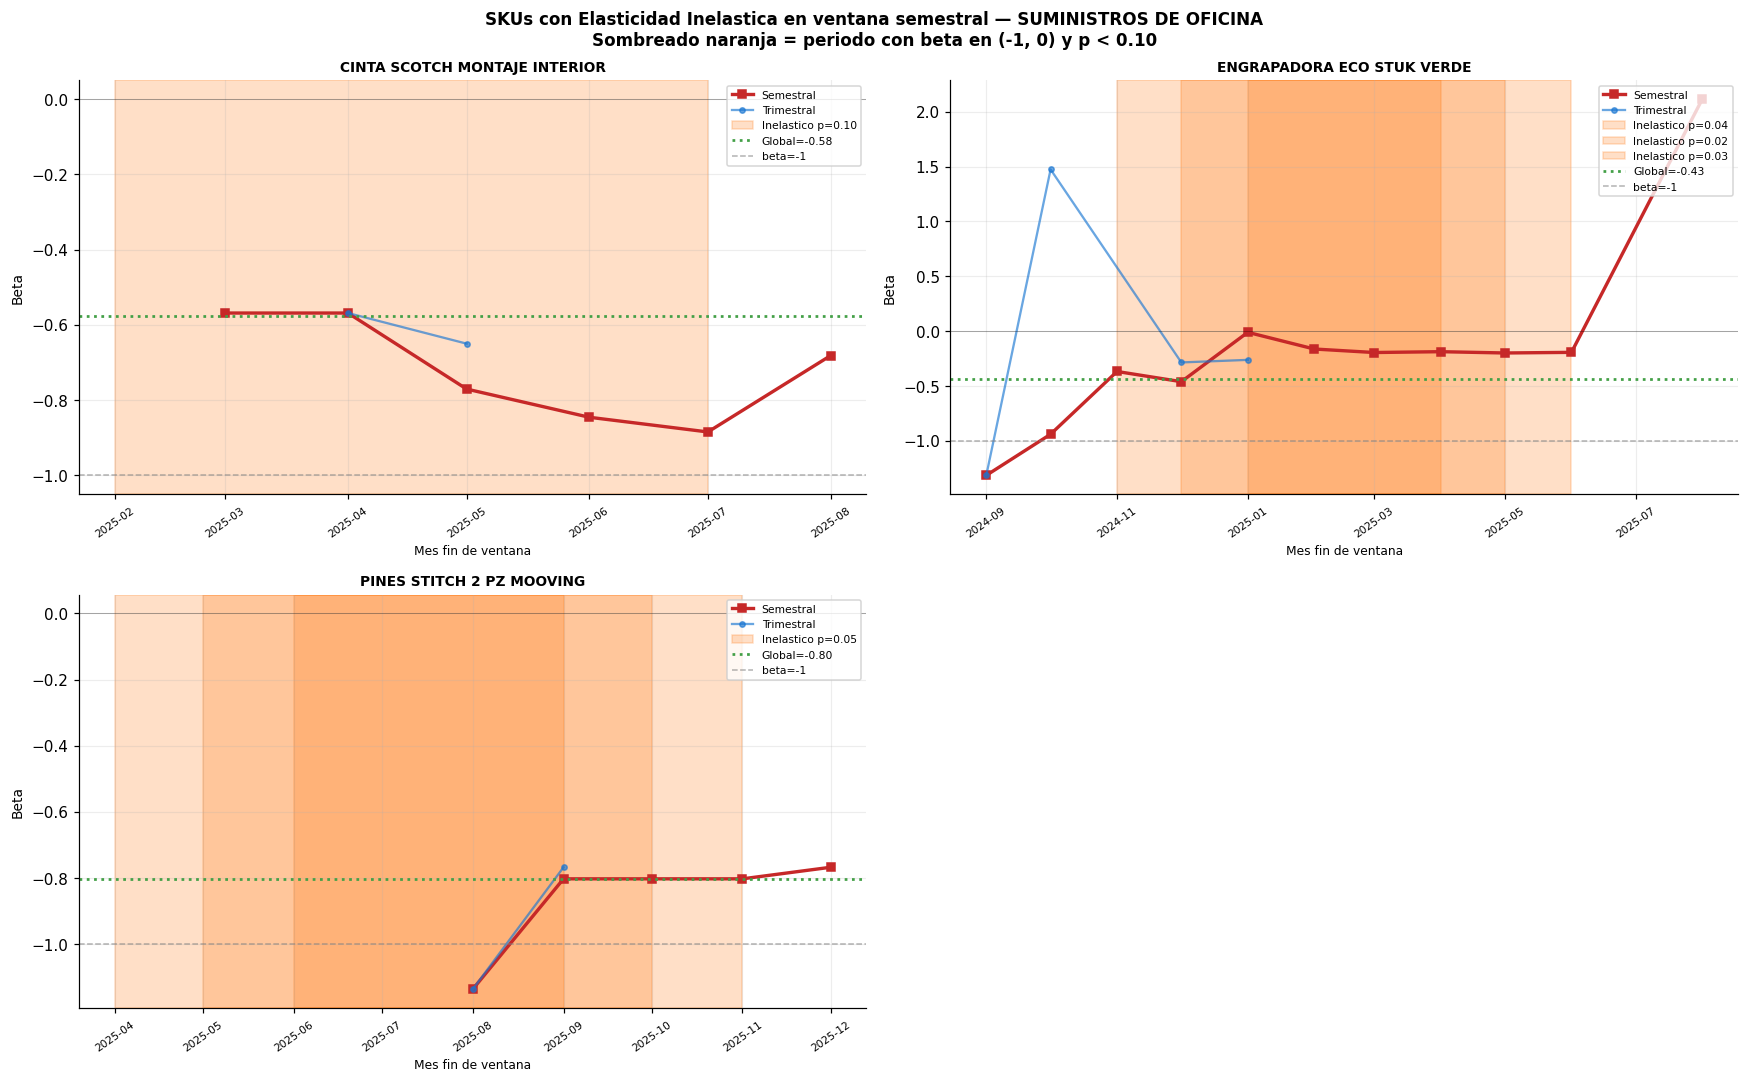

In [16]:
skus_inel = inel_sem["prod_nbr"].unique().tolist() if len(inel_sem) > 0 else []
if skus_inel:
    nc = min(2, len(skus_inel)); nr = (len(skus_inel)+1)//2
    fig, axes = plt.subplots(nr, nc, figsize=(16, 5*nr), squeeze=False)
    fig.suptitle(f"SKUs con Elasticidad Inelastica en ventana semestral — {CATEGORIA}\n"
                 "Sombreado naranja = periodo con beta en (-1, 0) y p < 0.10", fontsize=11, fontweight="bold")
    for idx, sku in enumerate(skus_inel):
        ax  = axes[idx//2][idx%2]
        d6  = df_sem[df_sem["prod_nbr"]==sku].sort_values("mes_fin_dt")
        d3  = df_trim[df_trim["prod_nbr"]==sku].sort_values("mes_fin_dt")
        nombre = d6["prod_nm"].iloc[0][:45] if len(d6)>0 else sku
        bm = df_mensual.loc[df_mensual["prod_nbr"]==sku,"beta"]
        if len(d6)>0: ax.plot(d6["mes_fin_dt"],d6["beta"],"s-",ms=5,lw=2.2,color="#C62828",label="Semestral")
        if len(d3)>1: ax.plot(d3["mes_fin_dt"],d3["beta"],"o-",ms=3.5,lw=1.5,color="#1976D2",alpha=0.65,label="Trimestral")
        for _, vrow in inel_sem[inel_sem["prod_nbr"]==sku].iterrows():
            ax.axvspan(pd.Period(vrow["mes_inicio"]).to_timestamp(),
                       pd.Period(vrow["mes_fin"]).to_timestamp(),
                       alpha=0.22, color="#FF6F00", label=f"Inelastico p={vrow['pval']:.2f}")
        if len(bm)>0: ax.axhline(bm.iloc[0],color="#43A047",ls=":",lw=1.8,label=f"Global={bm.iloc[0]:.2f}")
        ax.axhline(-1,color="gray",ls="--",lw=1,alpha=0.6,label="beta=-1")
        ax.axhline(0,color="black",ls="-",lw=0.5,alpha=0.4)
        ax.set_title(nombre, fontsize=9, fontweight="bold")
        ax.set_xlabel("Mes fin de ventana",fontsize=8); ax.set_ylabel("Beta",fontsize=9)
        ax.tick_params(axis="x",rotation=35,labelsize=7)
        h, l = ax.get_legend_handles_labels()
        seen=set(); uh=[]; ul=[]
        for hh,ll in zip(h,l):
            if ll not in seen: seen.add(ll); uh.append(hh); ul.append(ll)
        ax.legend(uh,ul,fontsize=7,loc="upper right"); ax.grid(alpha=0.22)
    for idx in range(len(skus_inel), nr*nc): axes[idx//2][idx%2].set_visible(False)
    plt.tight_layout(); plt.show()

---
## 9. Conclusion Ejecutiva

Resumen automatico del analisis con los hallazgos clave, candidatos a subir o
bajar precio, y las limitaciones del modelo.


In [17]:
import requests as _http

n_total   = mensual["prod_nbr"].nunique()
n_validos = len(df_mensual)
n_subir_g = len(rec[rec["recomendacion"]=="SUBIR PRECIO"])
n_bajar_g = len(rec[rec["recomendacion"]=="BAJAR / PROMOVER"])
n_norec_g = len(rec[rec["recomendacion"]=="NO RECOMENDABLE"])
n_inel    = int(inel_sem["prod_nbr"].nunique()) if len(inel_sem)>0 else 0
meses_data = carp["mes"].nunique()
cv_prom    = round(mensual.groupby("prod_nbr")["precio"].std().div(
                   mensual.groupby("prod_nbr")["precio"].mean()).mean()*100, 1)

cand_subir = inel_sem.sort_values("pval").iloc[0]["prod_nm"] if len(inel_sem)>0 else "ninguno con beta inelastica significativa"
cand_subir_mes = f"{inel_sem.sort_values('pval').iloc[0]['mes_inicio']} a {inel_sem.sort_values('pval').iloc[0]['mes_fin']}" if len(inel_sem)>0 else "N/A"
valid_promo = rec[(rec["recomendacion"]=="BAJAR / PROMOVER") & (rec["pval"]<0.10)]
cand_promo  = valid_promo.sort_values("beta").iloc[0]["prod_nm"] if len(valid_promo)>0 else "ver hoja Recomendaciones"
cand_beta   = round(valid_promo.sort_values("beta").iloc[0]["beta"],2) if len(valid_promo)>0 else float("nan")

prompt_llm = f"""Eres analista de revenue management para OfficeMax Mexico.
Escribe una conclusion ejecutiva de 3 parrafos (max 200 palabras) en espanol, sin titulos.
Datos:
- Categoria: {CATEGORIA}, {meses_data} meses, {n_total} SKUs ({n_validos} con modelo valido)
- Escenarios simulados: -10% y +10% de cambio de precio en {len(sim_base)} SKUs
- {n_subir_g + n_inel} candidatos subir precio (mejor: {cand_subir} en {cand_subir_mes})
- {n_bajar_g} candidatos promover (mejor: {cand_promo}, beta={cand_beta})
- {n_norec_g} no recomendables (baja significancia o elasticidad sospechosa)
- CV promedio de precio: {cv_prom}%
Formato: Parrafo 1 contexto | Parrafo 2 hallazgos | Parrafo 3 limitaciones"""

conclusion = None
for model in ["qwen2:latest","qwen2","llama3.2","llama3","mistral"]:
    try:
        r = _http.post("http://localhost:11434/api/generate",
                       json={"model":model,"prompt":prompt_llm,"stream":False}, timeout=90)
        if r.status_code == 200:
            txt = r.json().get("response","").strip()
            if len(txt) > 80:
                print(f"[Modelo: Ollama/{model}]\n")
                conclusion = txt; break
    except: break

if conclusion is None:
    cav1 = f"la variacion de precio observada es limitada (CV promedio {cv_prom}%), lo que reduce la precision de los betas"
    cav2 = "el modelo asume relacion log-lineal estable en el tiempo y no separa efectos de temporada ni competencia"
    conclusion = (
        f"En el departamento {CATEGORIA}, simulamos cambios de precio de -10% a +10% "
        f"en {len(sim_base)} SKUs seleccionados, usando regresion OLS log-log sobre "
        f"{n_validos} productos validos de {n_total} totales en {meses_data} meses de datos.\n\n"
        f"Encontramos que {n_subir_g + n_inel} productos podrian tolerar una subida de precio "
        f"({cand_subir} muestra elasticidad inelastica en {cand_subir_mes}), "
        f"{n_bajar_g} son mas adecuados para promocion ({cand_promo}, beta={cand_beta}), "
        f"y {n_norec_g} no deben recomendarse por baja significancia estadistica.\n\n"
        f"Los resultados son exploratorios porque {cav1}; ademas, {cav2}. "
        f"Se recomienda validar con pruebas de precio controladas antes de implementar cambios."
    )

print(conclusion)

En el departamento SUMINISTROS DE OFICINA, simulamos cambios de precio de -10% a +10% en 4 SKUs seleccionados, usando regresion OLS log-log sobre 130 productos validos de 173 totales en 28 meses de datos.

Encontramos que 3 productos podrian tolerar una subida de precio (ENGRAPADORA ECO STUK VERDE muestra elasticidad inelastica en 2024-12 a 2025-05), 3 son mas adecuados para promocion (IMANES REDONDOS BLANCO PERLA 6PZ STUK, beta=-2.66), y 122 no deben recomendarse por baja significancia estadistica.

Los resultados son exploratorios porque la variacion de precio observada es limitada (CV promedio 11.8%), lo que reduce la precision de los betas; ademas, el modelo asume relacion log-lineal estable en el tiempo y no separa efectos de temporada ni competencia. Se recomienda validar con pruebas de precio controladas antes de implementar cambios.
